**Equipe:**
- Matheus Virgolino Abilio da Silva - 124210975
- Jefferson Ribeiro Brasil - 123110470
- João Gabriel Eulálio Luiggi Ramos - 121110737
- José Vitor Barbosa Maciel - 120210954
- Pedro Wilson Silva de Sousa - 124211096

# 02 · EDA — Dados de Bilhetagem

## Objetivo
Explorar a relação entre condições climáticas e padrões de demanda no sistema de bilhetagem de Niterói (março/2026).

## Perguntas-guia

| # | Pergunta | Notebook |
|---|----------|----------|
| P1 | Existe variação no volume de embarques em dias adversos vs. tempo firme? | 02 |
| P2 | O comportamento difere entre perfis de passageiro (tipo de cartão)? | 02 |
| P3 | Como muda o perfil horário de embarques em dias adversos? | 02 + 03 |
| P4 | Há linhas mais vulneráveis ao clima que outras? | 02 |
| P5 | A queda na demanda é independente da qualidade do serviço? | 02 + 03 |

## Fontes de dados
- **Bilhetagem:** CSVs diários em `../data/data_challenge_netmob_2026/data/ticket_data/`
- **Clima:** `../data/meteorological_data.csv` (leituras horárias, estação Niterói)

---
## 0 · Configuração

### 0.1 · Imports

Bibliotecas utilizadas:
- `pandas` / `numpy` — manipulação e agregação de dados
- `matplotlib` / `seaborn` — visualizações
- `scipy.stats` — testes estatísticos (Kruskal-Wallis, Pearson, Spearman)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 20)
plt.rcParams.update({'figure.figsize': (12, 5), 'figure.dpi': 100})
sns.set_theme(style='whitegrid', palette='muted')

### 0.2 · Constantes e mapeamentos

Centralizar aqui facilita ajustes: trocar um threshold de chuva ou adicionar uma cor não exige buscar pelo notebook.

In [2]:
DATA_DIR     = Path('../data/data_challenge_netmob_2026/data/ticket_data')
WEATHER_PATH = Path('../data/meteorological_data.csv')

CARD_TYPE_MAP = {-1: 'Cash', 1: 'Standard', 2: 'Student', 3: 'Labor', 4: 'Senior'}
FARE_TYPE_MAP = {1: 'Free', 2: 'Electronic', 3: 'Cash'}

WEATHER_ORDER   = ['Clear', 'Light Rain', 'Moderate Rain', 'Heavy Rain / Storm']
WEATHER_PALETTE = {
    'Clear':              '#4CAF50',
    'Light Rain':         '#64B5F6',
    'Moderate Rain':      '#1565C0',
    'Heavy Rain / Storm': '#4A148C',
}

---
## 1 · Carga dos Dados de Bilhetagem

Cada arquivo CSV representa um dia de operação — uma linha por transação de passageiro.

| Coluna | Tipo | Descrição |
|--------|------|-----------|
| `transaction_date` | datetime (UTC) | Timestamp da validação |
| `card_type` | int | Tipo de cartão: −1=Cash, 1=Standard, 2=Student, 3=Labor, 4=Senior |
| `fare_type` | int | Tipo de tarifa: 1=Free, 2=Electronic, 3=Cash |
| `debited_amount` | float | Valor debitado (R$); 0.0 indica gratuidade |
| `integration_flag` | int | 2 = transferência/integração entre linhas |
| `route_name` | str | Identificador da linha de ônibus |
| `anon_user_id` | int | ID anonimizado do usuário |

In [3]:
dtypes = {
    'fare_type': 'int8', 'vehicle_number': 'int32', 'company_number': 'int16',
    'route_detail_id': 'int32', 'integration_flag': 'int8', 'card_type': 'int8',
    'debited_amount': 'float32', 'day_type': 'int8', 'day_period': 'int8',
    'anon_user_id': 'int32', 'route_name': 'str',
}

csv_files = sorted(DATA_DIR.glob('*.csv'))
print(f'Arquivos encontrados: {len(csv_files)}')

dfs = [pd.read_csv(f, dtype=dtypes, encoding='utf-8', parse_dates=['transaction_date'])
       for f in csv_files]

tickets = pd.concat(dfs, ignore_index=True)
print(f'Total de transações: {len(tickets):,}')
tickets.head(3)

Arquivos encontrados: 31


Total de transações: 6,790,681


,transaction_date,fare_type,vehicle_number,company_number,route_detail_id,integration_flag,card_type,debited_amount,view_type,route_name,day_type,day_period,anon_user_id
0,2026-03-01 00:00:02-03:00,2,2037,56,2713,1,1,4.45,VÁRZEA DAS MOÇAS - CENTRO,46,3,1,71220
1,2026-03-01 00:00:08-03:00,2,2037,56,2713,1,1,4.45,VÁRZEA DAS MOÇAS - CENTRO,46,3,1,371854
2,2026-03-01 00:00:16-03:00,2,2037,56,2713,1,1,4.45,VÁRZEA DAS MOÇAS - CENTRO,46,3,1,361148


---
## 2 · Pré-processamento

### 2.1 · Timezone e features temporais

Os timestamps chegam em **UTC**. Converter para **BRT (UTC−3)** é obrigatório antes de calcular hora do dia ou período — sem isso, os picos de hora de pico aparecem deslocados em 3 horas.

Features criadas:
- `date` — data normalizada, usada para agrupar por dia e fazer merge com clima
- `hour` — hora local (0–23), para análise de perfil horário
- `is_weekend` — sábado/domingo têm padrão de demanda distinto dos dias úteis

In [4]:
tickets['transaction_date'] = (
    pd.to_datetime(tickets['transaction_date'], utc=True)
    .dt.tz_convert('America/Sao_Paulo')
)

tickets['date']       = tickets['transaction_date'].dt.normalize()
tickets['hour']       = tickets['transaction_date'].dt.hour
tickets['is_weekend'] = tickets['transaction_date'].dt.dayofweek >= 5

print(f"Período: {tickets['date'].min().date()} → {tickets['date'].max().date()}")

Período: 2026-03-01 → 2026-03-31


### 2.2 · Features categóricas e flags de negócio

- `card_label` / `fare_label` — versões legíveis dos códigos numéricos (para plots e prints)
- `is_free` — embarques gratuitos (R$ 0,00); inclui benefícios por política (ex: idosos, estudantes)
- `is_transfer` — integração entre linhas; **não** representa uma nova viagem originada

In [5]:
tickets['card_label']  = tickets['card_type'].map(CARD_TYPE_MAP).fillna('Unknown')
tickets['fare_label']  = tickets['fare_type'].map(FARE_TYPE_MAP).fillna('Unknown')
tickets['is_free']     = tickets['debited_amount'] == 0.0
tickets['is_transfer'] = tickets['integration_flag'] == 2

### 2.3 · Qualidade dos dados

Verificação de nulos, distribuição dos tipos categóricos e range dos valores financeiros.

In [6]:
print('=== Nulos ===')
nulls = tickets.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else 'Nenhum nulo')

print('\n=== Distribuição card_type ===')
print(tickets['card_label'].value_counts())

print('\n=== Distribuição fare_type ===')
print(tickets['fare_label'].value_counts())

print('\n=== debited_amount (R$) ===')
print(tickets['debited_amount'].describe())
print(f"Valores negativos: {(tickets['debited_amount'] < 0).sum():,}")

=== Nulos ===


Nenhum nulo

=== Distribuição card_type ===


card_label
Standard    4085360
Senior       978640
Cash         922589
Student      759356
Labor         44736
Name: count, dtype: int64

=== Distribuição fare_type ===


fare_label
Electronic    4085360
Free          1792520
Cash           912801
Name: count, dtype: int64

=== debited_amount (R$) ===


count   6790681.00
mean          3.08
std           2.32
min           0.00
25%           0.00
50%           4.45
75%           4.45
max           5.60
Name: debited_amount, dtype: float64
Valores negativos: 0


---
## 3 · Dados Climáticos

### 3.1 · Carga e agregação diária

Os dados meteorológicos são leituras **horárias**. Precisamos da granularidade **diária** para cruzar com os embarques.

Agregações calculadas:
- `rain_mm` — precipitação acumulada no dia (soma)
- `temp_mean/max/min` — temperatura média, máxima e mínima
- `wind_max` — rajada máxima (pico de vento)
- `wind_mean` — velocidade média do vento

In [7]:
weather_raw = pd.read_csv(WEATHER_PATH)
weather_raw.columns = weather_raw.columns.str.strip()
weather_raw = weather_raw.rename(columns={
    'Timestamp (UTC)': 'timestamp_utc', 'Temp. Ins. (C)': 'temp_c',
    'Temp. Max. (C)': 'temp_max_c',    'Temp. Min. (C)': 'temp_min_c',
    'Wind Speed (m/s)': 'wind_speed',  'Wind Gust (m/s)': 'wind_gust',
    'Rain (mm)': 'rain_mm',
})
weather_raw['timestamp_utc'] = pd.to_datetime(weather_raw['timestamp_utc'], utc=True)
weather_raw['timestamp_brt'] = weather_raw['timestamp_utc'].dt.tz_convert('America/Sao_Paulo')
weather_raw['date']          = weather_raw['timestamp_brt'].dt.normalize()

weather_daily = weather_raw.groupby('date', as_index=False).agg(
    rain_mm   = ('rain_mm', 'sum'),
    temp_mean = ('temp_c', 'mean'),
    temp_max  = ('temp_max_c', 'max'),
    temp_min  = ('temp_min_c', 'min'),
    wind_max  = ('wind_gust', 'max'),
    wind_mean = ('wind_speed', 'mean'),
)
weather_daily.head()

,date,rain_mm,temp_mean,temp_max,temp_min,wind_max,wind_mean
0,2026-02-28 00:00:00-03:00,0.00,25.60,25.90,25.40,6.30,2.20
1,2026-03-01 00:00:00-03:00,4.60,24.10,28.80,22.10,8.80,1.55
2,2026-03-02 00:00:00-03:00,0.20,24.14,28.80,20.70,7.50,1.31
3,2026-03-03 00:00:00-03:00,0.00,25.37,29.70,21.30,7.30,1.26
4,2026-03-04 00:00:00-03:00,0.00,26.30,30.90,22.60,7.60,1.30


### 3.2 · Classificação climática

Categorizamos os dias com base na precipitação acumulada, usando limiares próximos aos do INMET:

| Categoria | Chuva diária acumulada |
|-----------|------------------------|
| Clear | < 1 mm |
| Light Rain | 1 – 10 mm |
| Moderate Rain | 10 – 25 mm |
| Heavy Rain / Storm | ≥ 25 mm |

`is_adverse = True` para Moderate e Heavy (chuva ≥ 10 mm) — critério usado nas análises P1–P4.

In [8]:
def classify_weather(rain):
    if rain < 1:  return 'Clear'
    if rain < 10: return 'Light Rain'
    if rain < 25: return 'Moderate Rain'
    return 'Heavy Rain / Storm'

weather_daily['weather_cat'] = pd.Categorical(
    weather_daily['rain_mm'].map(classify_weather),
    categories=WEATHER_ORDER, ordered=True
)
weather_daily['is_adverse'] = weather_daily['rain_mm'] >= 10

print(weather_daily['weather_cat'].value_counts().sort_index())

weather_cat
Clear                 22
Light Rain             6
Moderate Rain          4
Heavy Rain / Storm     0
Name: count, dtype: int64


### 3.3 · Visualização do período climático

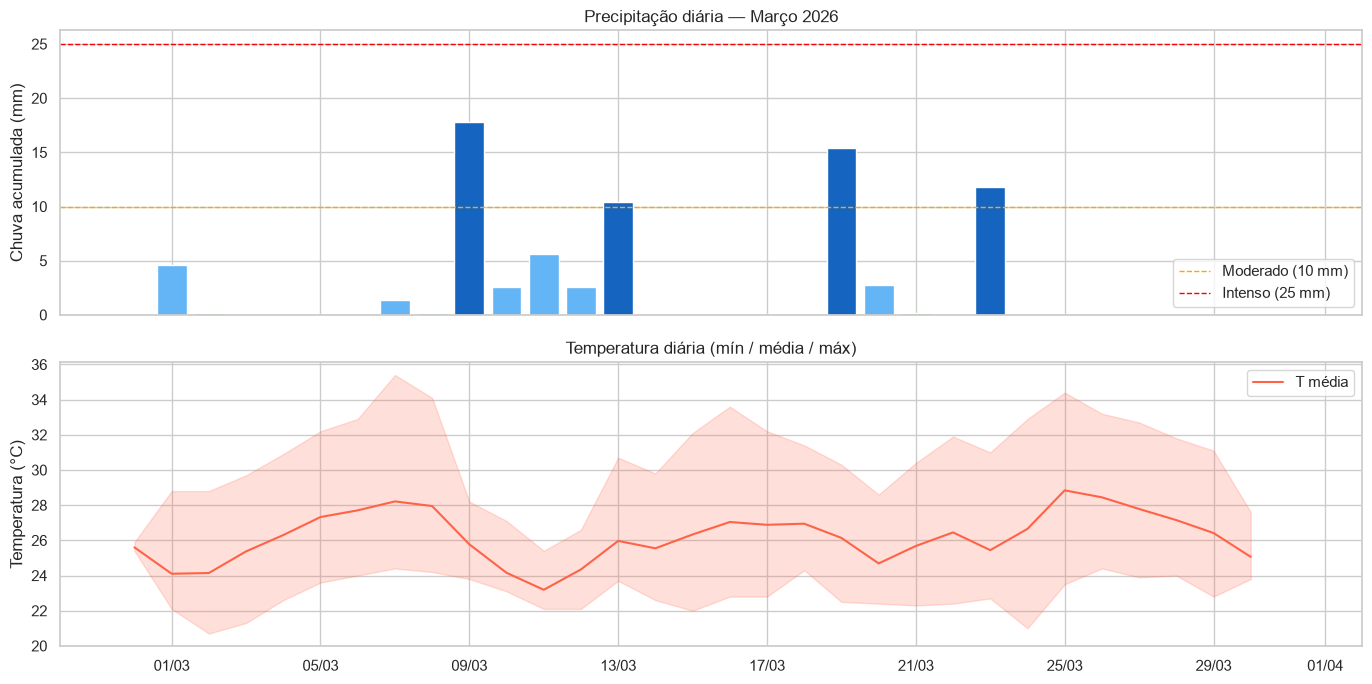

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].bar(weather_daily['date'], weather_daily['rain_mm'],
            color=[WEATHER_PALETTE[c] for c in weather_daily['weather_cat']], width=0.8)
axes[0].axhline(10, color='orange', linestyle='--', lw=1, label='Moderado (10 mm)')
axes[0].axhline(25, color='red',    linestyle='--', lw=1, label='Intenso (25 mm)')
axes[0].set_ylabel('Chuva acumulada (mm)')
axes[0].set_title('Precipitação diária — Março 2026')
axes[0].legend()

axes[1].plot(weather_daily['date'], weather_daily['temp_mean'], color='tomato', label='T média')
axes[1].fill_between(weather_daily['date'], weather_daily['temp_min'], weather_daily['temp_max'],
                     alpha=0.2, color='tomato')
axes[1].set_ylabel('Temperatura (°C)')
axes[1].set_title('Temperatura diária (mín / média / máx)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 4 · Dataset Diário Integrado

Agregamos as transações por dia e fazemos o merge com o clima por data.
Essa tabela é a base para todas as análises P1–P5.

| Coluna | Descrição |
|--------|-----------|
| `boardings` | Total de transações no dia |
| `unique_users` | Usuários distintos com cartão (exclui `anon_user_id = 0`) |
| `revenue` | Receita total (R$) |
| `free_rides` | Embarques gratuitos |
| `transfers` | Integrações entre linhas |
| `paid_boardings` | `boardings` − `free_rides` |

In [10]:
daily_tickets = tickets.groupby('date', as_index=False).agg(
    boardings    = ('transaction_date', 'count'),
    unique_users = ('anon_user_id', lambda x: (x != 0).sum()),
    revenue      = ('debited_amount', 'sum'),
    free_rides   = ('is_free', 'sum'),
    transfers    = ('is_transfer', 'sum'),
    is_weekend   = ('is_weekend', 'first'),
)
daily_tickets['paid_boardings'] = daily_tickets['boardings'] - daily_tickets['free_rides']

daily = daily_tickets.merge(weather_daily, on='date', how='inner')
print(f'Dias no dataset: {len(daily)}')
daily.head()

Dias no dataset: 31


,date,boardings,unique_users,revenue,free_rides,transfers,is_weekend,paid_boardings,rain_mm,temp_mean,temp_max,temp_min,wind_max,wind_mean,weather_cat,is_adverse
0,2026-03-01 00:00:00-03:00,63379,52376,214076.75,17368,7392,True,46011,4.60,24.10,28.80,22.10,8.80,1.55,Light Rain,False
1,2026-03-02 00:00:00-03:00,258057,223472,772387.31,88558,31126,False,169499,0.20,24.14,28.80,20.70,7.50,1.31,Clear,False
2,2026-03-03 00:00:00-03:00,267760,232736,801472.94,91415,32298,False,176345,0.00,25.37,29.70,21.30,7.30,1.26,Clear,False
3,2026-03-04 00:00:00-03:00,265886,231968,796198.81,90214,32629,False,175672,0.00,26.30,30.90,22.60,7.60,1.30,Clear,False
4,2026-03-05 00:00:00-03:00,269360,234105,809716.31,91156,32370,False,178204,0.00,27.32,32.20,23.60,8.70,1.57,Clear,False


---
## P1 · Volume de Passageiros × Categoria Climática

> *Existe variação significativa no volume de embarques em dias adversos vs. tempo firme?*

**Estratégia de análise:**
1. **Série temporal** com overlay de chuva — contexto visual do período
2. **Box plot** por categoria climática, separando dias úteis de fins de semana
3. **Teste de Kruskal-Wallis** — valida se as diferenças entre grupos são estatisticamente significativas (não paramétrico, indicado para grupos com poucos dias)

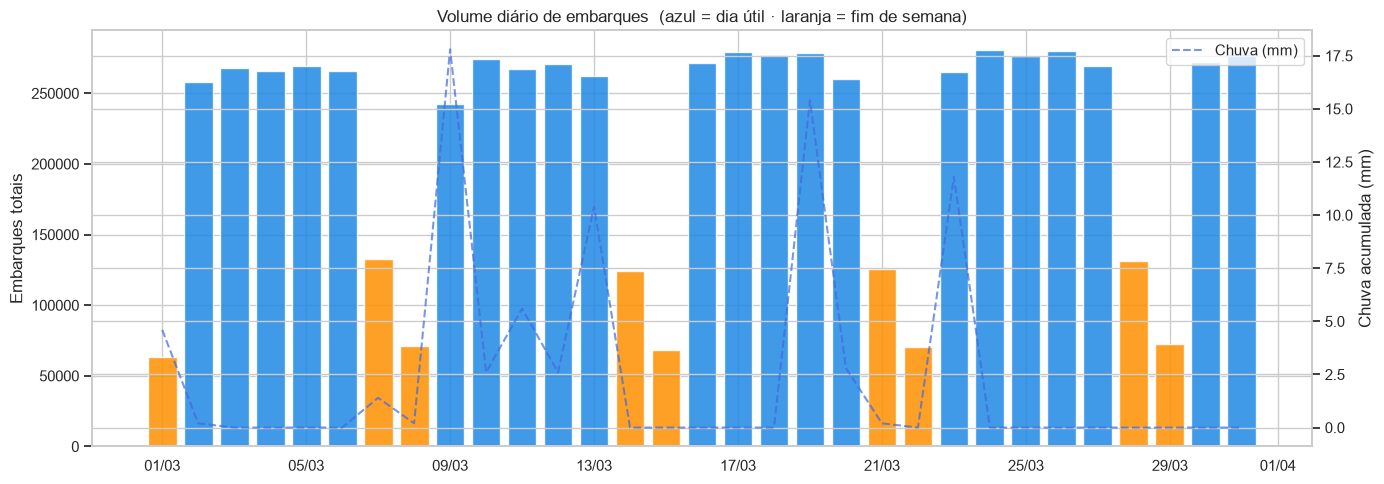

In [11]:
# Série temporal: volume diário com overlay de precipitação
fig, ax1 = plt.subplots(figsize=(14, 5))

colors_ts = daily['is_weekend'].map({True: '#FF8F00', False: '#1E88E5'})
ax1.bar(daily['date'], daily['boardings'], color=colors_ts, alpha=0.85, width=0.8)
ax1.set_ylabel('Embarques totais')
ax1.set_title('Volume diário de embarques  (azul = dia útil · laranja = fim de semana)')

ax2 = ax1.twinx()
ax2.plot(daily['date'], daily['rain_mm'], color='royalblue',
         lw=1.5, linestyle='--', alpha=0.7, label='Chuva (mm)')
ax2.set_ylabel('Chuva acumulada (mm)')
ax2.legend(loc='upper right')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

plt.tight_layout()
plt.show()

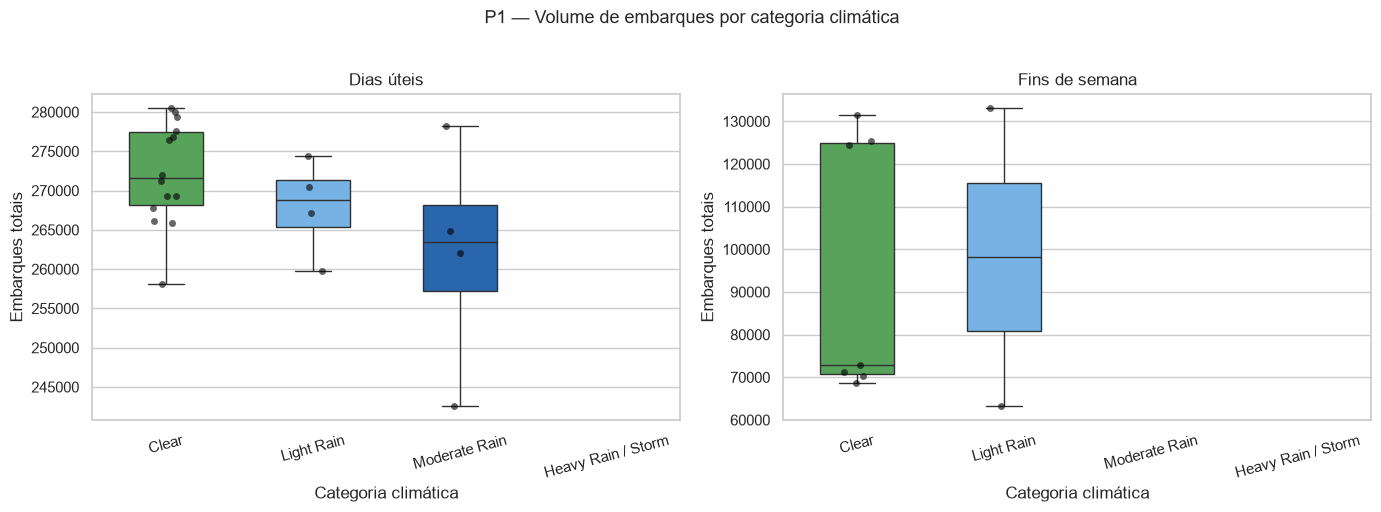

In [12]:
# Box plot: distribuição de embarques por categoria climática
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (is_wknd, label) in zip(axes, [(False, 'Dias úteis'), (True, 'Fins de semana')]):
    subset = daily[daily['is_weekend'] == is_wknd]
    sns.boxplot(data=subset, x='weather_cat', y='boardings', order=WEATHER_ORDER,
                palette=WEATHER_PALETTE, ax=ax, width=0.5)
    sns.stripplot(data=subset, x='weather_cat', y='boardings', order=WEATHER_ORDER,
                  color='black', size=5, alpha=0.6, ax=ax)
    ax.set_title(label)
    ax.set_xlabel('Categoria climática')
    ax.set_ylabel('Embarques totais')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('P1 — Volume de embarques por categoria climática', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# Kruskal-Wallis + variação percentual vs. dias claros
weekday = daily[~daily['is_weekend']].copy()

groups = [weekday.loc[weekday['weather_cat'] == cat, 'boardings'].values
          for cat in WEATHER_ORDER if cat in weekday['weather_cat'].values]

if len(groups) >= 2:
    stat, p = stats.kruskal(*groups)
    print(f'Kruskal-Wallis (dias úteis): H={stat:.2f}, p={p:.4f}')
    print('Diferença significativa (p < 0.05)' if p < 0.05 else 'Sem diferença significativa')

print('\n=== Mediana por categoria (dias úteis) ===')
print(weekday.groupby('weather_cat', observed=True)['boardings']
      .agg(['median', 'mean', 'count'])
      .rename(columns={'median': 'Mediana', 'mean': 'Média', 'count': 'N dias'}))

baseline = weekday.loc[weekday['weather_cat'] == 'Clear', 'boardings'].median()
print('\n=== Variação relativa vs. Clear ===')
for cat in WEATHER_ORDER[1:]:
    vals = weekday.loc[weekday['weather_cat'] == cat, 'boardings']
    if len(vals) > 0:
        print(f'  {cat}: {(vals.median() / baseline - 1) * 100:+.1f}%')

Kruskal-Wallis (dias úteis): H=3.15, p=0.2068
Sem diferença significativa

=== Mediana por categoria (dias úteis) ===
                Mediana     Média  N dias
weather_cat                              
Clear         271586.50 272172.14      14
Light Rain    268775.00 267934.50       4
Moderate Rain 263459.00 261934.75       4

=== Variação relativa vs. Clear ===
  Light Rain: -1.0%
  Moderate Rain: -3.0%


---
## P2 · Demanda por Perfil de Passageiro × Clima

> *O comportamento da demanda difere entre os perfis de passageiros?*

**Estratégia de análise:**
1. Composição geral do ridership por tipo de cartão — entender quem é a maioria
2. **Heatmap normalizado** (razão vs. dias Clear) por perfil × categoria climática — identificar quem é mais sensível
3. **Gráfico de linhas** para comparar a trajetória de sensibilidade entre perfis

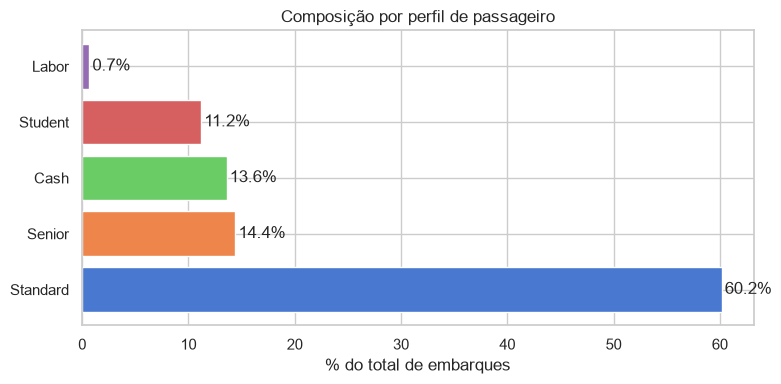

card_label  boardings   pct
  Standard    4085360 60.16
    Senior     978640 14.41
      Cash     922589 13.59
   Student     759356 11.18
     Labor      44736  0.66


In [14]:
# Composição geral: participação de cada perfil no total de embarques
profile_total = (
    tickets.groupby('card_label')['transaction_date']
    .count().sort_values(ascending=False).reset_index(name='boardings')
)
profile_total['pct'] = profile_total['boardings'] / profile_total['boardings'].sum() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(profile_total['card_label'], profile_total['pct'],
               color=sns.color_palette('muted', len(profile_total)))
for bar, pct in zip(bars, profile_total['pct']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center')
ax.set_xlabel('% do total de embarques')
ax.set_title('Composição por perfil de passageiro')
plt.tight_layout()
plt.show()
print(profile_total.to_string(index=False))

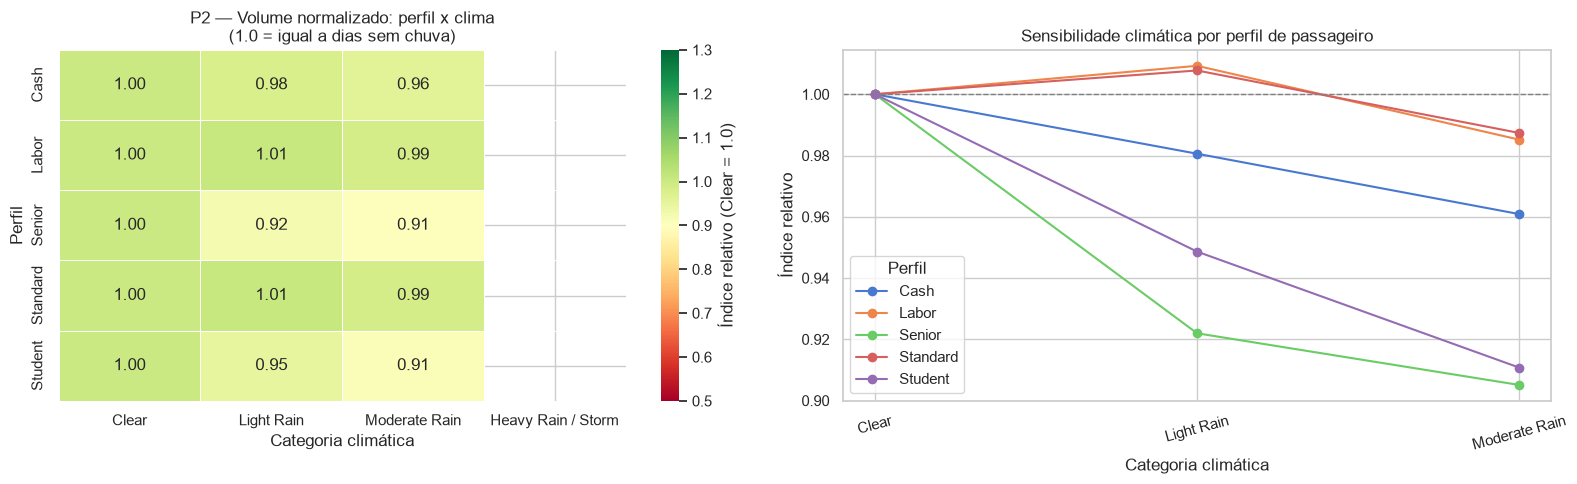

weather_cat  Clear  Light Rain  Moderate Rain  Heavy Rain / Storm
card_label                                                       
Cash          1.00        0.98           0.96                 NaN
Labor         1.00        1.01           0.99                 NaN
Senior        1.00        0.92           0.91                 NaN
Standard      1.00        1.01           0.99                 NaN
Student       1.00        0.95           0.91                 NaN


In [15]:
# Volume médio diário por perfil × categoria climática (dias úteis), normalizado vs. Clear
daily_profile = (
    tickets[~tickets['is_weekend']]
    .groupby(['date', 'card_label'], as_index=False)
    .agg(boardings=('transaction_date', 'count'))
)
daily_profile = daily_profile.merge(
    weather_daily[['date', 'weather_cat', 'is_adverse']], on='date'
)

pivot_mean = (
    daily_profile.groupby(['card_label', 'weather_cat'], observed=True)['boardings'].mean()
    .unstack('weather_cat').reindex(columns=WEATHER_ORDER)
)
pivot_norm = pivot_mean.div(pivot_mean['Clear'], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(pivot_norm, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0.5, vmax=1.3,
            ax=axes[0], linewidths=0.5, cbar_kws={'label': 'Índice relativo (Clear = 1.0)'})
axes[0].set_title('P2 — Volume normalizado: perfil x clima\n(1.0 = igual a dias sem chuva)')
axes[0].set_xlabel('Categoria climática')
axes[0].set_ylabel('Perfil')

for card in pivot_norm.index:
    axes[1].plot(WEATHER_ORDER, pivot_norm.loc[card, WEATHER_ORDER], marker='o', label=card)
axes[1].axhline(1.0, color='gray', linestyle='--', lw=1)
axes[1].set_xlabel('Categoria climática')
axes[1].set_ylabel('Índice relativo')
axes[1].set_title('Sensibilidade climática por perfil de passageiro')
axes[1].legend(title='Perfil')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()
print(pivot_norm.to_string())

---
## P3 · Perfil Horário da Demanda em Dias Adversos

> *Como muda a distribuição horária dos embarques em dias de chuva?*

**Estratégia de análise:**
1. Calcular o volume **médio por hora** para cada categoria climática (dias úteis)
2. Curvas horárias sobrepostas por categoria — comparar forma do perfil
3. Heatmap hora × categoria — visão condensada
4. Índice relativo hora a hora vs. dias Clear — identificar horários mais afetados

> **Headway e velocidade:** requerem dados GPS — ver `03_eda_mobility.ipynb`.

In [16]:
# Anotar categoria climática em cada transação via join por data
cat_dates = weather_daily.set_index('date')['weather_cat'].to_dict()
tickets['weather_cat'] = pd.Categorical(
    tickets['date'].map(cat_dates), categories=WEATHER_ORDER, ordered=True
)

# Volume total por hora × categoria (dias úteis)
hourly = (
    tickets[~tickets['is_weekend']]
    .groupby(['weather_cat', 'hour'], observed=True)['transaction_date']
    .count().reset_index(name='total')
)

# Normalizar pelo número de dias em cada categoria (média por dia)
days_per_cat = (
    daily[~daily['is_weekend']]
    .groupby('weather_cat', observed=True)['date'].count().to_dict()
)
hourly['avg_per_day'] = hourly.apply(
    lambda r: r['total'] / days_per_cat.get(r['weather_cat'], 1), axis=1
)

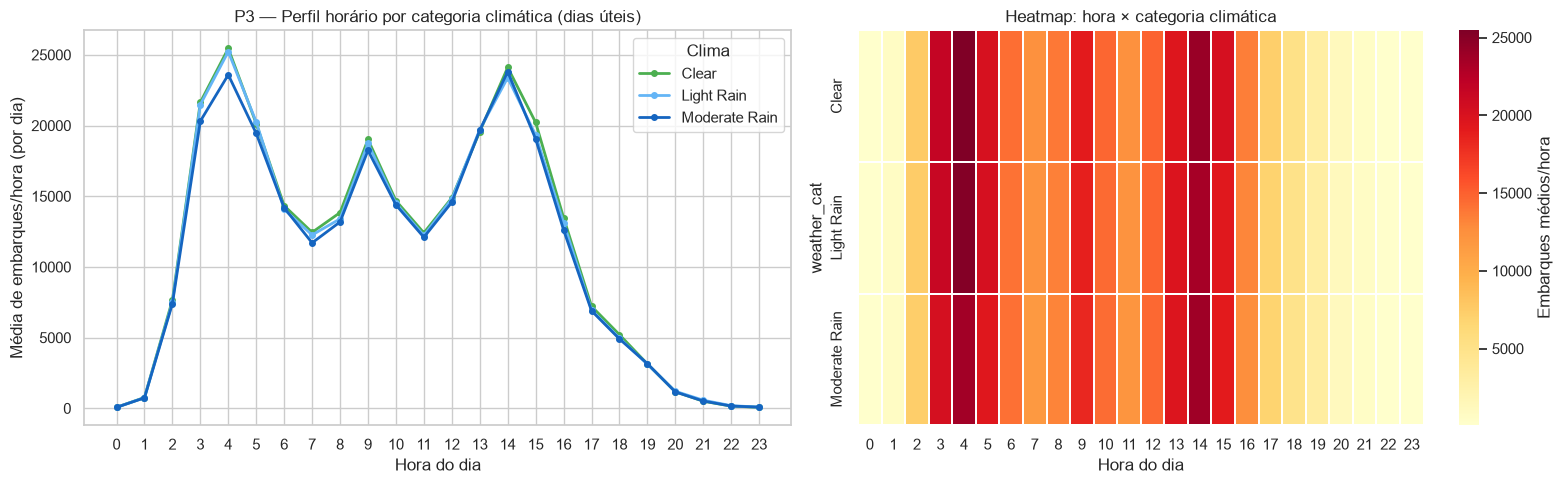

In [17]:
# Curvas horárias e heatmap por categoria climática
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for cat in WEATHER_ORDER:
    sub = hourly[hourly['weather_cat'] == cat]
    if sub.empty:
        continue
    axes[0].plot(sub['hour'], sub['avg_per_day'], label=cat,
                 color=WEATHER_PALETTE[cat], lw=2, marker='o', ms=4)

axes[0].set_xlabel('Hora do dia')
axes[0].set_ylabel('Média de embarques/hora (por dia)')
axes[0].set_title('P3 — Perfil horário por categoria climática (dias úteis)')
axes[0].legend(title='Clima')
axes[0].set_xticks(range(0, 24))

hourly_pivot = hourly.pivot(index='weather_cat', columns='hour', values='avg_per_day')
sns.heatmap(hourly_pivot, cmap='YlOrRd', ax=axes[1], linewidths=0.3,
            cbar_kws={'label': 'Embarques médios/hora'})
axes[1].set_title('Heatmap: hora × categoria climática')
axes[1].set_xlabel('Hora do dia')

plt.tight_layout()
plt.show()

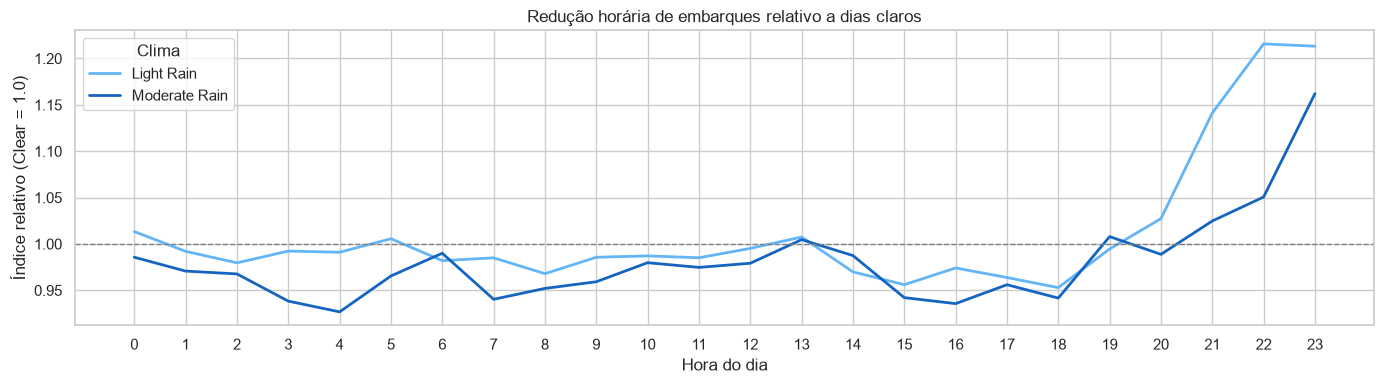

In [18]:
# Índice relativo por hora vs. dias Clear (quanto cada hora cai em relação ao padrão)
hourly_norm = hourly_pivot.div(hourly_pivot.loc['Clear'], axis=1)

fig, ax = plt.subplots(figsize=(14, 4))
for cat in WEATHER_ORDER[1:]:
    if cat in hourly_norm.index:
        ax.plot(hourly_norm.columns, hourly_norm.loc[cat],
                label=cat, color=WEATHER_PALETTE[cat], lw=2)
ax.axhline(1.0, color='gray', linestyle='--', lw=1)
ax.set_xlabel('Hora do dia')
ax.set_ylabel('Índice relativo (Clear = 1.0)')
ax.set_title('Redução horária de embarques relativo a dias claros')
ax.legend(title='Clima')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

---
## P4 · Resiliência por Linha de Ônibus

> *Quais linhas apresentam maior vulnerabilidade ao clima adverso?*

**Estratégia de análise:**
1. Calcular volume médio diário por linha separando dias claros de dias adversos
2. `drop_pct` = variação percentual (adverso / claro − 1) — métrica de vulnerabilidade
3. Filtrar linhas com volume mínimo (≥ 50 embarques/dia) e presença em ambos os cenários
4. Ranking visual dos extremos + scatter volume × sensibilidade

In [19]:
# Volume diário por linha (dias úteis)
daily_route = (
    tickets[~tickets['is_weekend']]
    .groupby(['date', 'route_name'], as_index=False)
    .agg(boardings=('transaction_date', 'count'))
)
daily_route = daily_route.merge(weather_daily[['date', 'weather_cat', 'is_adverse']], on='date')

# Manter apenas linhas com registro em AMBOS os cenários (clara E adversa)
clear_routes   = set(daily_route.loc[~daily_route['is_adverse'], 'route_name'])
adverse_routes = set(daily_route.loc[ daily_route['is_adverse'], 'route_name'])
daily_route    = daily_route[daily_route['route_name'].isin(clear_routes & adverse_routes)]

In [20]:
# Calcular drop_pct e aplicar filtro de volume mínimo
route_mean = (
    daily_route.groupby(['route_name', 'is_adverse'])['boardings'].mean()
    .unstack('is_adverse')
    .rename(columns={False: 'clear_mean', True: 'adverse_mean'})
    .dropna()
)
route_mean['drop_pct'] = (route_mean['adverse_mean'] / route_mean['clear_mean'] - 1) * 100
route_mean = route_mean[route_mean['clear_mean'] >= 50].copy()

print(f'Linhas analisadas: {len(route_mean)}')
route_mean.sort_values('drop_pct').head(10)

Linhas analisadas: 57


is_adverse,clear_mean,adverse_mean,drop_pct
route_name,,,
62,650.33,178.00,-72.63
43.2,225.50,182.75,-18.96
17,190.89,159.25,-16.57
34,1498.67,1268.75,-15.34
52A,1300.89,1113.00,-14.44
54,603.00,542.00,-10.12
33F,877.94,790.00,-10.02
41BC,2202.78,1990.50,-9.64
66C,87.44,79.50,-9.09


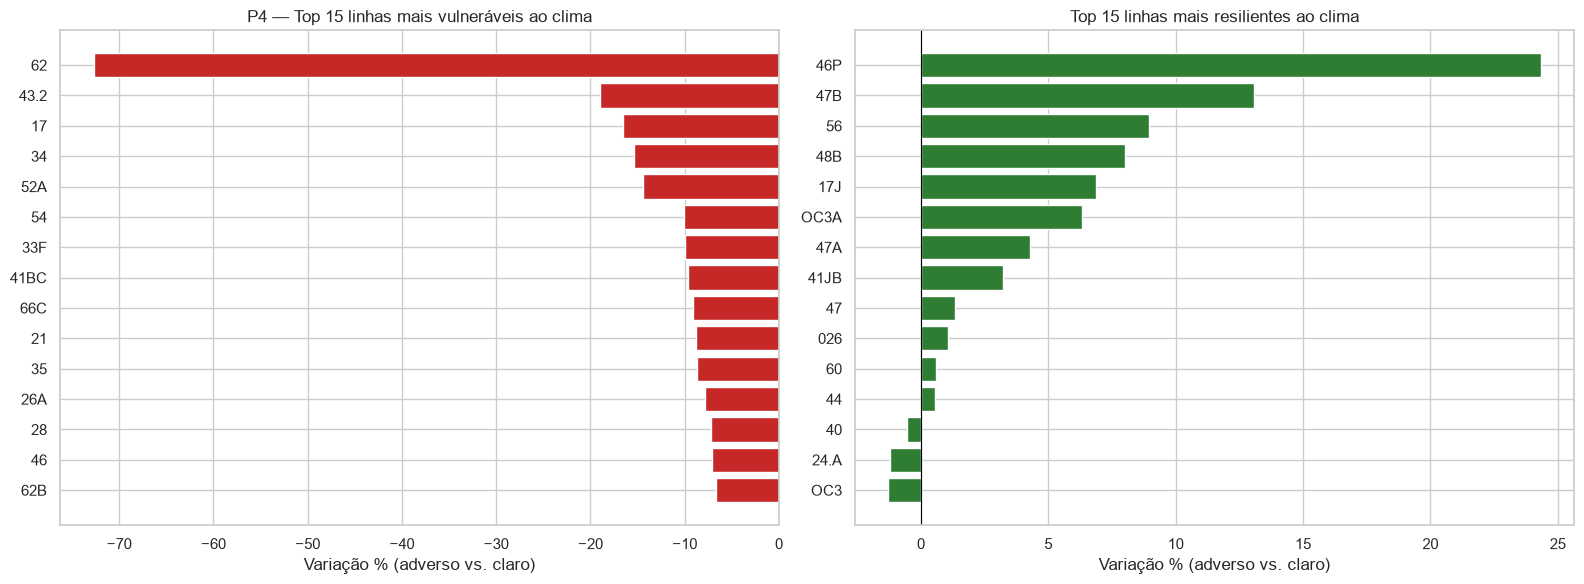

In [21]:
# Ranking: top 15 mais vulneráveis e mais resilientes
TOP_N = 15
most_vulnerable = route_mean.nsmallest(TOP_N, 'drop_pct')
most_resilient  = route_mean.nlargest(TOP_N, 'drop_pct')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(most_vulnerable.index.astype(str), most_vulnerable['drop_pct'], color='#C62828')
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_xlabel('Variação % (adverso vs. claro)')
axes[0].set_title(f'P4 — Top {TOP_N} linhas mais vulneráveis ao clima')
axes[0].invert_yaxis()

axes[1].barh(most_resilient.index.astype(str), most_resilient['drop_pct'], color='#2E7D32')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('Variação % (adverso vs. claro)')
axes[1].set_title(f'Top {TOP_N} linhas mais resilientes ao clima')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

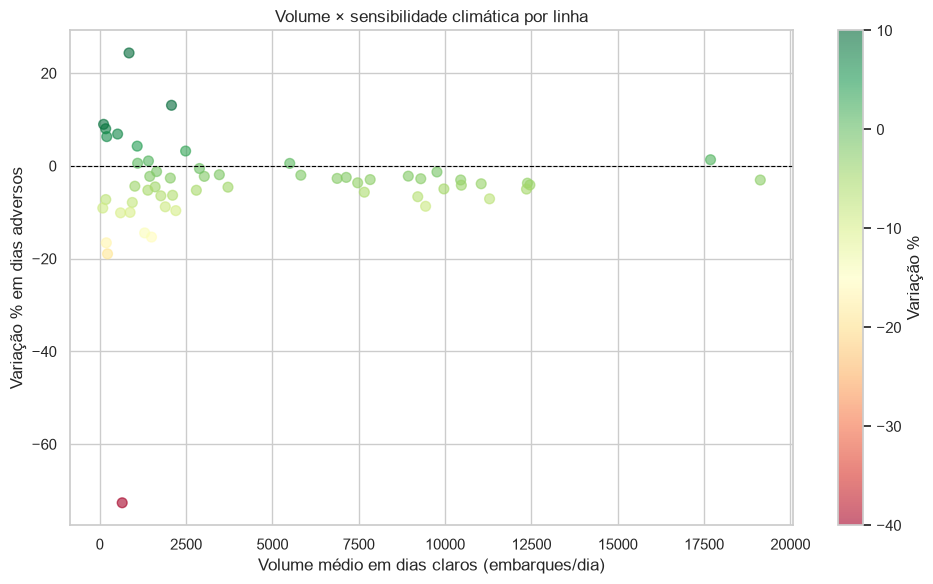

Pearson r (volume × queda%): 0.071  p=0.6005


In [22]:
# Scatter: volume em dias claros vs. sensibilidade climática
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(route_mean['clear_mean'], route_mean['drop_pct'],
                alpha=0.6, s=50, c=route_mean['drop_pct'], cmap='RdYlGn', vmin=-40, vmax=10)
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('Volume médio em dias claros (embarques/dia)')
ax.set_ylabel('Variação % em dias adversos')
ax.set_title('Volume × sensibilidade climática por linha')
plt.colorbar(sc, ax=ax, label='Variação %')
plt.tight_layout()
plt.show()

r, p = stats.pearsonr(route_mean['clear_mean'], route_mean['drop_pct'])
print(f'Pearson r (volume × queda%): {r:.3f}  p={p:.4f}')

---
## P5 · Demanda × Qualidade do Serviço

> *A queda na demanda ocorre independentemente do serviço, ou é amplificada por ele?*

**Abordagem neste notebook** (variáveis climáticas → demanda):
1. Scatter de cada variável climática vs. embarques diários — Pearson
2. Spearman para relações não-lineares
3. **Lag-1**: a chuva de ontem influencia a demanda de hoje? (efeito residual no dia seguinte)
4. Queda horária em dias Heavy Rain vs. Clear — onde a queda é mais concentrada

> **Análise headway × demanda (qualidade de serviço):** ver `03_eda_mobility.ipynb`.

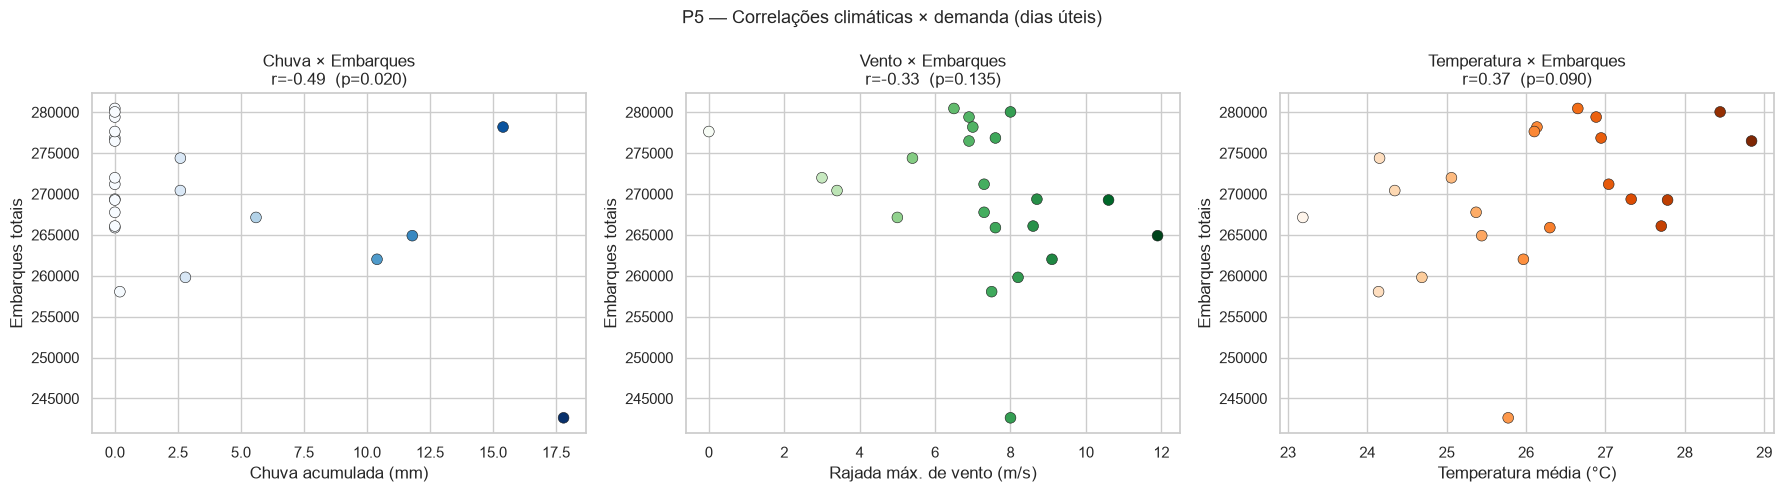

In [23]:
# Scatter: variáveis climáticas vs. embarques diários (dias úteis)
weekday = daily[~daily['is_weekend']].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(weekday['rain_mm'], weekday['boardings'],
                c=weekday['rain_mm'], cmap='Blues', s=60, edgecolors='k', lw=0.4)
r_b, p_b = stats.pearsonr(weekday['rain_mm'], weekday['boardings'])
axes[0].set_xlabel('Chuva acumulada (mm)')
axes[0].set_ylabel('Embarques totais')
axes[0].set_title(f'Chuva × Embarques\nr={r_b:.2f}  (p={p_b:.3f})')

axes[1].scatter(weekday['wind_max'].fillna(0), weekday['boardings'],
                c=weekday['wind_max'].fillna(0), cmap='Greens', s=60, edgecolors='k', lw=0.4)
r_w, p_w = stats.pearsonr(weekday['wind_max'].fillna(0), weekday['boardings'])
axes[1].set_xlabel('Rajada máx. de vento (m/s)')
axes[1].set_ylabel('Embarques totais')
axes[1].set_title(f'Vento × Embarques\nr={r_w:.2f}  (p={p_w:.3f})')

temp_filled = weekday['temp_mean'].fillna(weekday['temp_mean'].mean())
axes[2].scatter(temp_filled, weekday['boardings'],
                c=temp_filled, cmap='Oranges', s=60, edgecolors='k', lw=0.4)
r_t, p_t = stats.pearsonr(temp_filled, weekday['boardings'])
axes[2].set_xlabel('Temperatura média (°C)')
axes[2].set_ylabel('Embarques totais')
axes[2].set_title(f'Temperatura × Embarques\nr={r_t:.2f}  (p={p_t:.3f})')

plt.suptitle('P5 — Correlações climáticas × demanda (dias úteis)', fontsize=13)
plt.tight_layout()
plt.show()

In [24]:
# Correlação de Spearman — não assume linearidade
print('=== Spearman ===')
for var, label in [('rain_mm', 'Chuva'), ('wind_max', 'Vento'), ('temp_mean', 'Temperatura')]:
    col = weekday[var].fillna(0)
    r_s, p_s = stats.spearmanr(col, weekday['boardings'])
    print(f'{label:15s}  rho={r_s:+.3f}  p={p_s:.4f}')

=== Spearman ===
Chuva            rho=-0.485  p=0.0220
Vento            rho=-0.514  p=0.0143
Temperatura      rho=+0.303  p=0.1701


Chuva D-1 × Embarques D  rho=-0.178  p=0.4406


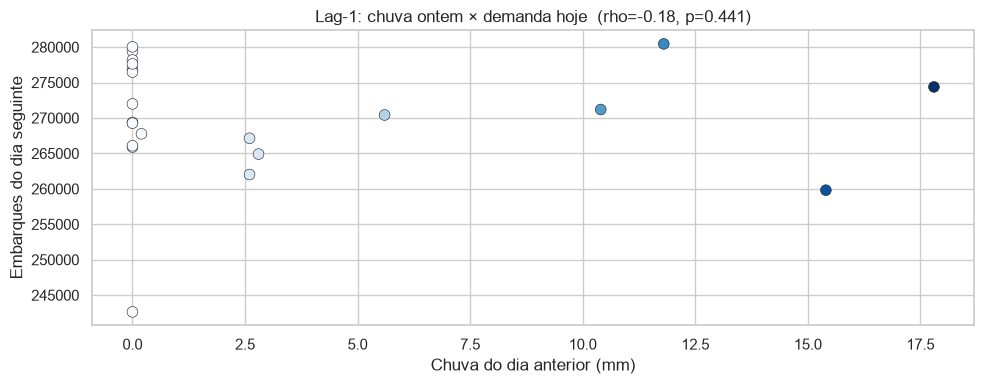

In [25]:
# Lag-1: chuva do dia anterior vs. embarques de hoje
ws = weekday.sort_values('date').copy()
ws['rain_lag1'] = ws['rain_mm'].shift(1)
lag1 = ws.dropna(subset=['rain_lag1'])

r_lag, p_lag = stats.spearmanr(lag1['rain_lag1'], lag1['boardings'])
print(f'Chuva D-1 × Embarques D  rho={r_lag:+.3f}  p={p_lag:.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(lag1['rain_lag1'], lag1['boardings'],
           c=lag1['rain_lag1'], cmap='Blues', s=60, edgecolors='k', lw=0.4)
ax.set_xlabel('Chuva do dia anterior (mm)')
ax.set_ylabel('Embarques do dia seguinte')
ax.set_title(f'Lag-1: chuva ontem × demanda hoje  (rho={r_lag:.2f}, p={p_lag:.3f})')
plt.tight_layout()
plt.show()

In [26]:
# Queda horária: Heavy Rain / Storm vs. Clear
h_clear = hourly[hourly['weather_cat'] == 'Clear']
h_heavy = hourly[hourly['weather_cat'] == 'Heavy Rain / Storm']

if not h_heavy.empty and not h_clear.empty:
    merged_h = h_clear.merge(h_heavy, on='hour', suffixes=('_clear', '_heavy'))
    merged_h['diff_pct'] = (merged_h['avg_per_day_heavy'] / merged_h['avg_per_day_clear'] - 1) * 100

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(merged_h['hour'], merged_h['diff_pct'],
           color=['#C62828' if v < 0 else '#2E7D32' for v in merged_h['diff_pct']])
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xlabel('Hora do dia')
    ax.set_ylabel('Variação % vs. dias claros')
    ax.set_title('P5 — Queda horária: Heavy Rain / Storm vs. Clear')
    ax.set_xticks(range(0, 24))
    plt.tight_layout()
    plt.show()
else:
    print('Dados insuficientes de dias Heavy Rain / Storm.')

Dados insuficientes de dias Heavy Rain / Storm.


---
## Síntese

| # | Pergunta | Método principal | Evidência produzida |
|---|----------|-----------------|---------------------|
| P1 | Volume × clima | Kruskal-Wallis + box plot | Variação % mediana por categoria climática |
| P2 | Perfil × clima | Heatmap normalizado + linhas | Índice relativo por `card_type` |
| P3 | Perfil horário | Curvas horárias + heatmap + índice relativo | Deslocamento/achatamento dos picos |
| P4 | Resiliência por linha | Ranking + scatter | `drop_pct` por `route_name` |
| P5 | Demanda × serviço | Pearson / Spearman / lag-1 / queda horária | Correlações chuva → demanda |

---

**Próximo passo:** `03_eda_mobility.ipynb` — headway e velocidade para completar P3 e P5.